In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/squid-dataset/train.json


In [14]:
!pip install transformers datasets
!pip install faiss-cpu
!pip install rouge-score

In [15]:
import json
import pandas as pd
import numpy as np
import math
import torch

from sklearn.feature_extraction.text import TfidfVectorizer

import torch.nn.functional as F
from tqdm import tqdm

import networkx as nx
import faiss

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


from rouge_score import rouge_scorer

In [16]:
file_path = '/kaggle/input/squid-dataset/train.json'


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
from transformers import AutoTokenizer , AutoModel, pipeline
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval().cuda()

tokenizer_G = AutoTokenizer.from_pretrained("google/flan-t5-base")
model_G = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to("cuda" if torch.cuda.is_available() else "cpu")

qa_model = pipeline("question-answering")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


In [19]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

In [20]:
#functions

def convert_squad_data_to_dataframe(file_path, cnt):
    with open(file_path, 'r') as f:
        squad_dict = json.load(f)
        data = squad_dict['data']
        rows = []
        for article in data:
            for paragraph in article['paragraphs']:
                context = paragraph['context']
                for qa in paragraph['qas']:
                    question = qa['question']
                    qid = qa['id']
                    is_impossible = qa.get('is_impossible', False)
                    answers = qa['answers'] if not is_impossible else []
                    if answers:
                        for answer in answers:
                            rows.append({
                                'context': context,
                                'question': question,
                                'qid': qid,
                                'answer': answer['text'],
                                'answer_start': answer['answer_start'],
                                'c_id': cnt
                            })
                    else:
                        rows.append({
                            'context': context,
                            'question': question,
                            'qid': qid,
                            'answer': '',
                            'answer_start': -1,
                            'c_id': cnt
                        })
                cnt += 1
        return pd.DataFrame(rows)

# Mean Pooling Function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state 
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    pooled = torch.sum(token_embeddings * input_mask_expanded, dim=1) / input_mask_expanded.sum(dim=1)
    return pooled

# Encode Single Batch of Texts
def encode_text(texts):
    encoded_input = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)

    with torch.no_grad():
        model_output = model(**encoded_input)
    
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)  # L2 normalize

    return sentence_embeddings.detach().cpu().numpy()


def encode_in_batches(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch_texts = texts[i:i + batch_size]
        batch_embeddings = encode_text(batch_texts)
        all_embeddings.append(batch_embeddings)
    return np.vstack(all_embeddings)

def dcg(scores):
    return sum([rel / math.log2(idx + 2) for idx, rel in enumerate(scores)])

def build_knowledge_graph(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)["data"]

    G = nx.DiGraph()
    question_answer_map = {}

    for article in data:
        title = article["title"]
        G.add_node(title, type="Article")

        for para in article['paragraphs']:
            context = para['context']
            G.add_node(context, type="Context")
            G.add_edge(title, context, relation="has_context")

            for qa in para['qas']:
                question = qa['question']
                G.add_node(question, type="Question")
                G.add_edge(context, question, relation="asks")

                if not qa['is_impossible']:
                    answers = [ans['text'] for ans in qa['answers']]
                    answer = answers[0] if answers else "No Answer"
                else:
                    answer = "No Answer"

                G.add_node(answer, type="Answer")
                G.add_edge(question, answer, relation="answered_by")
                question_answer_map[question] = answer

    print(f"\u2705 KG built: {len(G.nodes)} nodes / {len(G.edges)} edges")
    return G, question_answer_map

def retrieve_from_kg(question, question_answer_map):
    for kg_question in question_answer_map:
        if question.strip().lower() == kg_question.strip().lower():
            return question_answer_map[kg_question], "KG-Exact"
    return "No Answer", "KG-Fallback"

def enhance_kg_answer(question, kg_answer):
    prompt = f"Improve the answer: '{kg_answer}' for the question: '{question}'"
    inputs = tokenizer_G(prompt, return_tensors="pt", padding=True, truncation=True).to(model_G.device)
    with torch.no_grad():
        outputs = model_G.generate(**inputs, max_length=64)
    return tokenizer_G.decode(outputs[0], skip_special_tokens=True)


In [21]:
cnt = 0
data = convert_squad_data_to_dataframe(file_path, cnt)

# Drop duplicate contexts
documents = data[['context', 'c_id']].drop_duplicates().reset_index(drop=True)

# Create mapping for questions to their correct context IDs
questionContext = dict(zip(data['question'], data['c_id']))

# Vectorize contexts using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(documents['context'])

# Convert sparse to dense and normalize for FAISS
X_dense = X.toarray().astype(np.float32)
faiss.normalize_L2(X_dense)

# Build FAISS index
index = faiss.IndexFlatIP(X_dense.shape[1])
index.add(X_dense)


texts = documents['context'].tolist()
doc_embeddings = encode_in_batches(texts, batch_size=32)
dim = doc_embeddings.shape[1]
doc_embeddings = np.array(doc_embeddings)

# Evaluation

questions = list(questionContext.keys())

Q= questions

kg_graph, question_answer_map = build_knowledge_graph(file_path)

Encoding: 100%|██████████| 595/595 [00:37<00:00, 15.68it/s]


✅ KG built: 214334 nodes / 279558 edges


In [22]:
# import pandas as pd
# import numpy as np
# from tqdm import tqdm
# import torch
# import torch.nn.functional as F

# metric_names = ["rouge1", "rouge2", "rougeL", "em", "f1"]

# def score_answer(pred, gold):
#     scores = scorer.score(gold, pred)
#     rouge1 = scores['rouge1'].fmeasure
#     rouge2 = scores['rouge2'].fmeasure
#     rougeL = scores['rougeL'].fmeasure
#     em = int(pred.strip().lower() == gold.strip().lower())

#     pred_tokens = pred.lower().split()
#     gold_tokens = gold.lower().split()
#     common = set(pred_tokens) & set(gold_tokens)
#     if not common:
#         f1 = 0.0
#     else:
#         precision = len(common) / len(pred_tokens)
#         recall = len(common) / len(gold_tokens)
#         f1 = 2 * precision * recall / (precision + recall)
#     return rouge1, rouge2, rougeL, em, f1

# def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
#     qa_max_scores = []
#     kg_scores = []
#     best_of_all_scores = []

#     for idx in tqdm(range(min(len(question), max_samples)), desc=f"Evaluating Top-{k}", leave=True, ncols=80):
#         ques = question[idx]

#         # Vector search
#         query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
#         faiss.normalize_L2(query_vector)
#         distances, indices = index.search(query_vector, k)
#         predictions = indices[0]

#         # Ground truth
#         actual_index = questionContext[ques]
#         try:
#             actual_ans = data.loc[(data["question"] == ques) & (data["c_id"] == actual_index), "answer"].values[0]
#         except IndexError:
#             continue  # Skip if ground truth not found

#         # Semantic rerank
#         top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
#         query_embedding = encode_text([ques])
#         top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
#         query_tensor = torch.tensor(query_embedding).float().to(device)
#         top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
#         query_tensor = F.normalize(query_tensor, p=2, dim=1)
#         sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
#         reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
#         reranked_predictions = [predictions[i] for i in reranked_indices[:10]]

#         # QA answers (top 10 by relevance → top 3 by score)
#         qa_scores = []
#         for pred_idx in reranked_predictions:
#             context = documents.loc[pred_idx, 'context']
#             output = qa_model(question=ques, context=context)
#             answer = output['answer']
#             score = output.get('score', 0)
#             qa_scores.append((score, answer))

#         qa_scores.sort(reverse=True, key=lambda x: x[0])
#         qa_top3_answers = [x[1] for x in qa_scores[:3]]
#         qa_metric_scores = [score_answer(ans, actual_ans) for ans in qa_top3_answers]

#         # Max of QA
#         qa_max = np.stack(qa_metric_scores).max(axis=0)
#         qa_max_scores.append(qa_max)

#         # KG
#         kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
#         # kg_answer = enhance_kg_answer(ques, kg_answer)
#         kg_metric_score = score_answer(kg_answer, actual_ans)
#         kg_scores.append(kg_metric_score)

#         # Best among all 4 (3 QA + 1 KG)
#         all_scores = qa_metric_scores + [kg_metric_score]
#         best_all = np.stack(all_scores).max(axis=0)
#         best_of_all_scores.append(best_all)

#     return {
#         "qa_max": pd.DataFrame(qa_max_scores, columns=metric_names),
#         "kg_only": pd.DataFrame(kg_scores, columns=metric_names),
#         "best_all": pd.DataFrame(best_of_all_scores, columns=metric_names)
#     }

# # === Run Script ===
# questions = list(questionContext.keys())
# rerank_values = [50]
# final_result = []

# for r in rerank_values:
#     print(f"\nEvaluating with rerank_top_k = {r} ...")
#     result = compute_metrics(
#         question=questions,
#         questionContext=questionContext,
#         index=index,
#         k=300,
#         max_samples=5,
#         rerank_top_k=r
#     )
#     result["rerank_top_k"] = r
#     final_result.append(result)

In [23]:
# import pandas as pd
# import numpy as np
# from tqdm import tqdm
# import torch
# import torch.nn.functional as F
# from sklearn.preprocessing import normalize
# from transformers import pipeline

# # === Config ===
# metric_names = ["rouge1", "rouge2", "rougeL", "em", "f1"]

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # === Caches ===
# question_embedding_cache = {}

# # === Metric Function ===
# def score_answer(pred, gold):
#     pred = pred.strip().lower()
#     gold = gold.strip().lower()
#     em = int(pred == gold)

#     pred_tokens = pred.split()
#     gold_tokens = gold.split()
#     common = set(pred_tokens) & set(gold_tokens)
#     if not common:
#         f1 = 0.0
#     else:
#         precision = len(common) / len(pred_tokens)
#         recall = len(common) / len(gold_tokens)
#         f1 = 2 * precision * recall / (precision + recall)

#     # Simplified ROUGE as overlap ratio for efficiency
#     def overlap_ratio(n):
#         pred_ngrams = set(zip(*[pred_tokens[i:] for i in range(n)]))
#         gold_ngrams = set(zip(*[gold_tokens[i:] for i in range(n)]))
#         if not pred_ngrams or not gold_ngrams:
#             return 0.0
#         return len(pred_ngrams & gold_ngrams) / len(gold_ngrams)

#     rouge1 = overlap_ratio(1)
#     rouge2 = overlap_ratio(2)
#     rougeL = overlap_ratio(1)  # Approximated by unigram for speed

#     return rouge1, rouge2, rougeL, em, f1

# # === Main Function ===
# def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
#     qa_max_scores, kg_scores, best_of_all_scores = [], [], []

#     for idx in tqdm(range(min(len(question), max_samples)), desc=f"Evaluating Top-{k}", ncols=80):
#         ques = question[idx]
#         actual_index = questionContext.get(ques)
#         if actual_index is None:
#             continue

#         # Get ground truth
#         try:
#             actual_ans = data.loc[(data["question"] == ques) & (data["c_id"] == actual_index), "answer"].values[0]
#         except IndexError:
#             continue

#         # === Vector Search ===
#         query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
#         faiss.normalize_L2(query_vector)
#         distances, indices = index.search(query_vector, k)
#         predictions = indices[0]

#         # === Semantic Reranking ===
#         query_embedding = question_embedding_cache.get(ques)
#         if query_embedding is None:
#             query_embedding = encode_text([ques])
#             question_embedding_cache[ques] = query_embedding

#         query_tensor = torch.tensor(query_embedding).float().to(device)
#         top_k_embeddings = np.array([doc_embeddings[i] for i in predictions[:rerank_top_k]])
#         top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)

#         query_tensor = F.normalize(query_tensor, p=2, dim=1)
#         top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)

#         sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
#         reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
#         reranked_predictions = [predictions[i] for i in reranked_indices[:5]]  # Top 5 for speed

#         # === QA Inference (Batched) ===
#         qa_inputs = [{"question": ques, "context": documents.loc[i, 'context']} for i in reranked_predictions]
#         outputs = qa_model(qa_inputs)

#         # Ensure list
#         if isinstance(outputs, dict):
#             outputs = [outputs]

#         qa_scores = [(out.get("score", 0), out["answer"]) for out in outputs if out and "answer" in out]
#         qa_scores.sort(reverse=True, key=lambda x: x[0])
#         qa_top_answers = [x[1] for x in qa_scores[:2]]  # Top 2 answers

#         qa_metric_scores = [score_answer(ans, actual_ans) for ans in qa_top_answers]
#         qa_max = np.stack(qa_metric_scores).max(axis=0)
#         qa_max_scores.append(qa_max)

#         # === KG Answer ===
#         kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
#         kg_answer = enhance_kg_answer(ques, kg_answer)
#         kg_metric_score = score_answer(kg_answer, actual_ans)
#         kg_scores.append(kg_metric_score)

#         # === Best of All ===
#         all_scores = qa_metric_scores + [kg_metric_score]
#         best_all = np.stack(all_scores).max(axis=0)
#         best_of_all_scores.append(best_all)

#     return {
#         "qa_max": pd.DataFrame(qa_max_scores, columns=metric_names),
#         "kg_only": pd.DataFrame(kg_scores, columns=metric_names),
#         "best_all": pd.DataFrame(best_of_all_scores, columns=metric_names)
#     }

# # === Runner ===
# questions = list(questionContext.keys())
# rerank_values = [50]
# final_result = []

# for r in rerank_values:
#     print(f"\nEvaluating with rerank_top_k = {r} ...")
#     result = compute_metrics(
#         question=questions,
#         questionContext=questionContext,
#         index=index,
#         k=300,
#         max_samples=1000,
#         rerank_top_k=r
#     )
#     result["rerank_top_k"] = r
#     final_result.append(result)


In [24]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F
from sklearn.preprocessing import normalize
from transformers import pipeline

# === Config ===
metric_names = ["rouge1", "rouge2", "rougeL", "em", "f1"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Caches ===
question_embedding_cache = {}

# === Metric Function ===
def score_answer(pred, gold):
    pred = pred.strip().lower()
    gold = gold.strip().lower()
    em = int(pred == gold)

    pred_tokens = pred.split()
    gold_tokens = gold.split()
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        f1 = 0.0
    else:
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(gold_tokens)
        f1 = 2 * precision * recall / (precision + recall)

    def overlap_ratio(n):
        pred_ngrams = set(zip(*[pred_tokens[i:] for i in range(n)]))
        gold_ngrams = set(zip(*[gold_tokens[i:] for i in range(n)]))
        if not pred_ngrams or not gold_ngrams:
            return 0.0
        return len(pred_ngrams & gold_ngrams) / len(gold_ngrams)

    rouge1 = overlap_ratio(1)
    rouge2 = overlap_ratio(2)
    rougeL = overlap_ratio(1)  # Simplified
    return rouge1, rouge2, rougeL, em, f1

# === Main Function ===
def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    qa_max_scores, kg_scores, best_of_all_scores = [], [], []
    qa1_kg_scores, qa1_qa2_kg_scores = [], []

    for idx in tqdm(range(min(len(question), max_samples)), desc=f"Evaluating Top-{k}", ncols=80):
        ques = question[idx]
        actual_index = questionContext.get(ques)
        if actual_index is None:
            continue

        try:
            actual_ans = data.loc[(data["question"] == ques) & (data["c_id"] == actual_index), "answer"].values[0]
        except IndexError:
            continue

        # === Vector Search ===
        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)
        predictions = indices[0]

        # === Semantic Reranking ===
        query_embedding = question_embedding_cache.get(ques)
        if query_embedding is None:
            query_embedding = encode_text([ques])
            question_embedding_cache[ques] = query_embedding

        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions[:rerank_top_k]])
        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)

        query_tensor = F.normalize(query_tensor, p=2, dim=1)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)

        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:5]]

        # === QA Inference (Batched) ===
        qa_inputs = [{"question": ques, "context": documents.loc[i, 'context']} for i in reranked_predictions]
        outputs = qa_model(qa_inputs)

        if isinstance(outputs, dict):
            outputs = [outputs]

        qa_scores = [(out.get("score", 0), out["answer"]) for out in outputs if out and "answer" in out]
        qa_scores.sort(reverse=True, key=lambda x: x[0])
        qa_top_answers = [x[1] for x in qa_scores[:2]]  # Top 2 answers

        qa_metric_scores = [score_answer(ans, actual_ans) for ans in qa_top_answers]
        qa_max = np.stack(qa_metric_scores).max(axis=0)
        qa_max_scores.append(qa_max)

        # === KG Answer ===
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
        kg_answer = enhance_kg_answer(ques, kg_answer)
        kg_metric_score = score_answer(kg_answer, actual_ans)
        kg_scores.append(kg_metric_score)

        # === Best of All ===
        all_scores = qa_metric_scores + [kg_metric_score]
        best_all = np.stack(all_scores).max(axis=0)
        best_of_all_scores.append(best_all)

        # === New Combinations ===
        if len(qa_metric_scores) >= 2:
            qa1_kg = np.maximum(qa_metric_scores[0], kg_metric_score)
            qa1_qa2_kg = np.maximum.reduce([qa_metric_scores[0], qa_metric_scores[1], kg_metric_score])
        else:
            qa1_kg = np.maximum(qa_metric_scores[0], kg_metric_score)
            qa1_qa2_kg = qa1_kg  # fallback

        qa1_kg_scores.append(qa1_kg)
        qa1_qa2_kg_scores.append(qa1_qa2_kg)

    return {
        "qa_max": pd.DataFrame(qa_max_scores, columns=metric_names),
        "kg_only": pd.DataFrame(kg_scores, columns=metric_names),
        "best_all": pd.DataFrame(best_of_all_scores, columns=metric_names),
        "qa1_kg": pd.DataFrame(qa1_kg_scores, columns=metric_names),
        "qa1_qa2_kg": pd.DataFrame(qa1_qa2_kg_scores, columns=metric_names),
    }

# === Run Evaluation ===
questions = list(questionContext.keys())
rerank_values = [50]
final_result = []

for r in rerank_values:
    print(f"\nEvaluating with rerank_top_k = {r} ...")
    result = compute_metrics(
        question=questions,
        questionContext=questionContext,
        index=index,
        k=300,
        max_samples=86769,
        rerank_top_k=r
    )
    result["rerank_top_k"] = r
    final_result.append(result)



Evaluating with rerank_top_k = 50 ...


Evaluating Top-300:   0%|                             | 0/86769 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/pipelines/question_answering.py:390: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
Evaluating Top-300: 100%|███████████████| 86769/86769 [5:22:27<00:00,  4.48it/s]


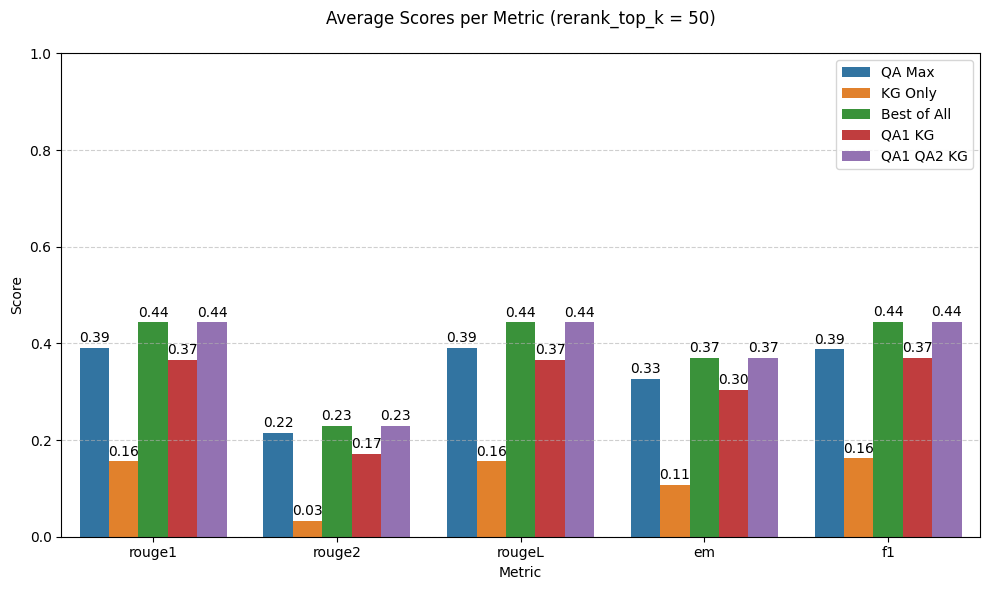

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Collect average scores for each metric/system
bar_data = []

for res in final_result:
    r = res["rerank_top_k"]
    qa_avg = res["qa_max"].mean()
    kg_avg = res["kg_only"].mean()
    best_avg = res["best_all"].mean()
    qa1_kg_avg = res["qa1_kg"].mean()
    qa1_qa2_kg_avg = res["qa1_qa2_kg"].mean()
    

    for metric in ["rouge1", "rouge2", "rougeL", "em", "f1"]:
        bar_data.append({
            "Metric": metric,
            "Score": qa_avg[metric],
            "System": "QA Max",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": kg_avg[metric],
            "System": "KG Only",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": best_avg[metric],
            "System": "Best of All",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": qa1_kg_avg[metric],
            "System": "QA1 KG",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": qa1_qa2_kg_avg[metric],
            "System": "QA1 QA2 KG",
            "rerank_top_k": r
        })

# Step 2: Create DataFrame
df_bar = pd.DataFrame(bar_data)

# Step 3: Plot grouped bar chart with annotations
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_bar,
    x="Metric",
    y="Score",
    hue="System"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=2)


# Finalize plot
plt.title(f"Average Scores per Metric (rerank_top_k = {final_result[0]['rerank_top_k']})\n")

plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()